In [1]:
import h5py
import matplotlib.pyplot as plt
import os
from pathlib import Path
import numpy as np
import pandas as pd

from scipy.stats import median_abs_deviation
from PIL import Image

In [3]:
def plot_corr(x, y):
    plt.figure()
    plt.scatter(x, y)
    print(np.corrcoef(x, y))

In [6]:
! ls ../../Computer_Vision_system/data/baseline

baseline_features_test.h5


In [15]:
# ── load baseline ───────────────────────────────────────────────
with h5py.File("../../Computer_Vision_system/data/baseline/baseline_features.h5", "r") as f:
    features = f["feature_matrix"][:]        # (n_images, 249, 11)
    valid = f["valid_mask"][:]               # (n_images, 249)
    names = [n.decode() for n in f["features_name"][:]]
    filenames = [n.decode() for n in f["image_filenames"][:]]
    
    # metadata
    print(f"Created: {f.attrs['created_at']}")
    print(f"Shape:   {features.shape}  →  {len(filenames)} images × {features.shape[1]} mirrors × {len(names)} features")

# ── quick sanity check ──────────────────────────────────────────
print(f"Valid:   {valid.sum()} / {valid.size} ({100*valid.mean():.1f}%)")
print(f"NaNs:    {np.isnan(features).sum()}")

# ── flatten to DataFrame for EDA ────────────────────────────────
# one row per (image, mirror) pair
idx = np.argwhere(valid)  # only valid entries
rows = features[idx[:, 0], idx[:, 1], :]

df = pd.DataFrame(rows, columns=names)
df["image_idx"] = idx[:, 0]
df["mirror_id"] = idx[:, 1]
df["filename"] = df["image_idx"].map(dict(enumerate(filenames)))

df.head()

Created: 2026-04-01T15:31:56.744544+00:00
Shape:   (224, 249, 11)  →  224 images × 249 mirrors × 11 features
Valid:   55776 / 55776 (100.0%)
NaNs:    0


,glcm_contrast,glcm_dissimilarity,glcm_homogeneity,glcm_energy,glcm_correlation,lbp_entropy,lbp_uniformity,sobel_mean,laplacian_mean,laplacian_std,edge_density,image_idx,mirror_id,filename
0,1803.795532,18.462845,0.241276,0.098648,0.828799,3.128510,0.193760,9.007812,114.382980,108.128128,0.270978,0,0,IRCamM1T20251005_071000M.jpg
1,1792.660034,18.631193,0.190850,0.078805,0.636254,3.167997,0.200142,9.585938,117.246117,107.854050,0.261524,0,1,IRCamM1T20251005_071000M.jpg
2,1175.129639,15.348817,0.189505,0.072719,0.739959,3.140893,0.210594,9.601562,118.318062,110.206665,0.252643,0,2,IRCamM1T20251005_071000M.jpg
3,1650.738281,14.827993,0.297274,0.079412,0.422861,3.149953,0.175379,9.289062,115.409584,113.257538,0.162644,0,3,IRCamM1T20251005_071000M.jpg
4,1115.773804,14.490035,0.191523,0.050342,0.552598,3.206565,0.179762,9.882812,116.815239,110.499344,0.230833,0,4,IRCamM1T20251005_071000M.jpg


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3735 entries, 0 to 3734
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   glcm_contrast       3735 non-null   float32
 1   glcm_dissimilarity  3735 non-null   float32
 2   glcm_homogeneity    3735 non-null   float32
 3   glcm_energy         3735 non-null   float32
 4   glcm_correlation    3735 non-null   float32
 5   lbp_entropy         3735 non-null   float32
 6   lbp_uniformity      3735 non-null   float32
 7   sobel_mean          3735 non-null   float32
 8   laplacian_mean      3735 non-null   float32
 9   laplacian_std       3735 non-null   float32
 10  edge_density        3735 non-null   float32
 11  image_idx           3735 non-null   int64  
 12  mirror_id           3735 non-null   int64  
 13  filename            3735 non-null   object 
dtypes: float32(11), int64(2), object(1)
memory usage: 248.2+ KB


In [5]:
df.keys()

Index(['glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity',
       'glcm_energy', 'glcm_correlation', 'lbp_entropy', 'lbp_uniformity',
       'sobel_mean', 'laplacian_mean', 'laplacian_std', 'edge_density',
       'image_idx', 'mirror_id', 'filename'],
      dtype='object')

In [10]:
features_keys_list = [
    'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation', 
    'lbp_entropy', 'lbp_uniformity',
    'sobel_mean', 'laplacian_mean', 'laplacian_std', 'edge_density'
]

In [35]:
filenames

['IRCamM1T20251005_071000M.jpg',
 'IRCamM1T20251005_072000M.jpg',
 'IRCamM1T20251005_073000M.jpg',
 'IRCamM1T20251005_074000M.jpg',
 'IRCamM1T20251005_075000M.jpg',
 'IRCamM1T20251005_103000M.jpg',
 'IRCamM1T20251005_104000M.jpg',
 'IRCamM1T20251005_151000M.jpg',
 'IRCamM1T20251005_152000M.jpg',
 'IRCamM1T20251005_155000M.jpg',
 'IRCamM1T20251005_160000M.jpg',
 'IRCamM1T20251005_165000M.jpg',
 'IRCamM1T20251006_071000M.jpg',
 'IRCamM1T20251006_072000M.jpg',
 'IRCamM1T20251006_073000M.jpg']

In [59]:
stack_img = []

adata_path = Path("/media/pgliwny/ADATA HD3303/Computer_Vision_system/data/MAGIC/images_for_analysis")

for f in filenames:
    print(f)
    img_path = adata_path / f
    img = np.array(Image.open(img_path))
    stack_img.append(img)

stack = np.array(stack_img)

median_img = np.median(stack, axis=0).astype(np.uint8)
mean_img = np.mean(stack, axis=0).astype(np.uint8)

IRCamM1T20251005_071000M.jpg
IRCamM1T20251005_072000M.jpg
IRCamM1T20251005_073000M.jpg
IRCamM1T20251005_074000M.jpg
IRCamM1T20251005_075000M.jpg
IRCamM1T20251005_103000M.jpg
IRCamM1T20251005_104000M.jpg
IRCamM1T20251005_151000M.jpg
IRCamM1T20251005_152000M.jpg
IRCamM1T20251005_155000M.jpg
IRCamM1T20251005_160000M.jpg
IRCamM1T20251005_165000M.jpg
IRCamM1T20251006_071000M.jpg
IRCamM1T20251006_072000M.jpg
IRCamM1T20251006_073000M.jpg


In [57]:
stack.shape

(15, 2560, 1920, 3)

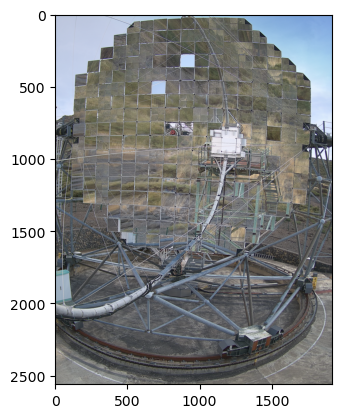

In [56]:
plt.imshow(mean_img)

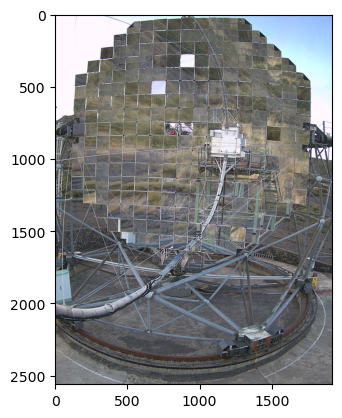

In [58]:
plt.imshow(median_img)

## 1. Baseline statystyczny per lustro
 
- Dla każdego lustra policz medianę i MAD (median absolute deviation) każdego feature'a 

In [14]:
features.shape

(15, 249, 11)

In [5]:
median_feat = np.median(features[:, :, :], axis=0)
median_abs_dev_feat = median_abs_deviation(features[:, :, :], axis=0)
print(median_feat.shape)
print(median_abs_dev_feat.shape)

(249, 11)
(249, 11)


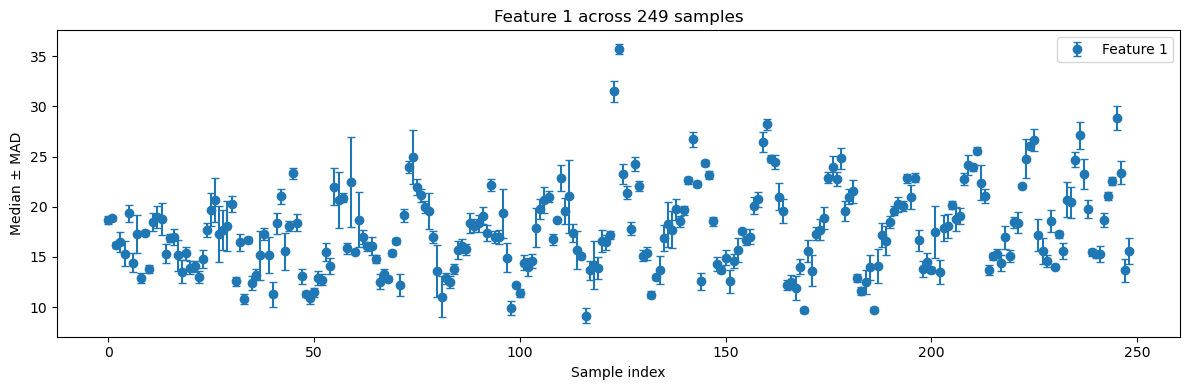

In [6]:
feature_idx = 1
plt.figure(figsize=(12, 4))
plt.errorbar(
    range(249),
    median_feat[:, feature_idx],
    yerr=median_abs_dev_feat[:, feature_idx],  # był błąd: [: 0] zamiast [:, 0]
    fmt='o',
    capsize=3,
    label=f'Feature {feature_idx}'
)
plt.xlabel('Sample index')
plt.ylabel('Median ± MAD')
plt.title(f'Feature {feature_idx} across 249 samples')
plt.legend()
plt.tight_layout()
plt.show()

0.9224475


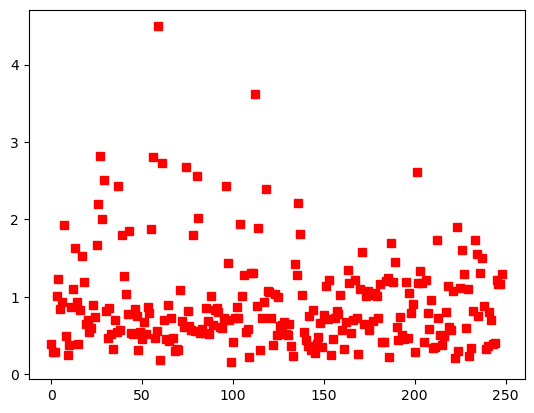

In [34]:
plt.plot(median_abs_dev_feat[:, feature_idx], 'rs')
print(np.mean(median_abs_dev_feat[:, feature_idx]))

## One mirror

In [30]:
def plot_baseline_from_feature(mirror_id, feature_name):
    df_one_mirror = df[df["mirror_id"] == mirror_id].reset_index()
    plt.figure()
    df_one_mirror[feature_name].plot()
    plt.xlabel("images")
    plt.ylabel(feature_name)
    plt.title(mirror_id)
    plt.show()

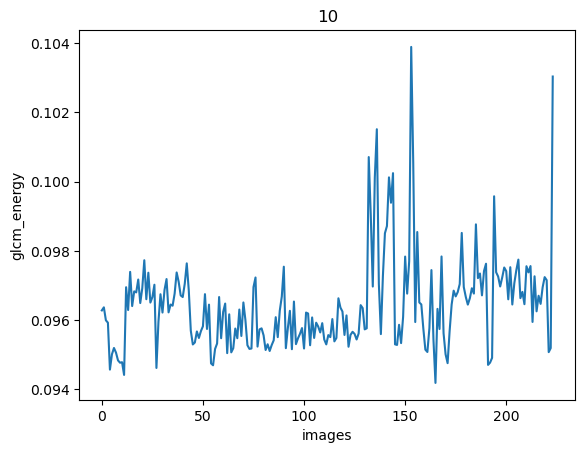

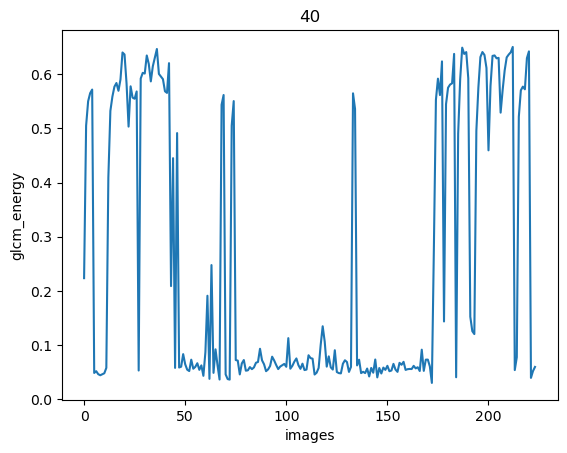

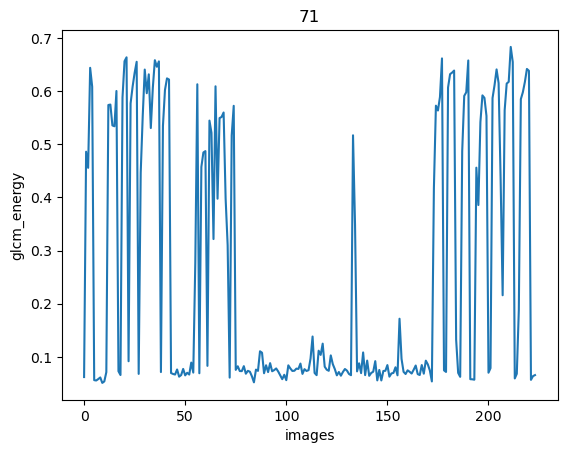

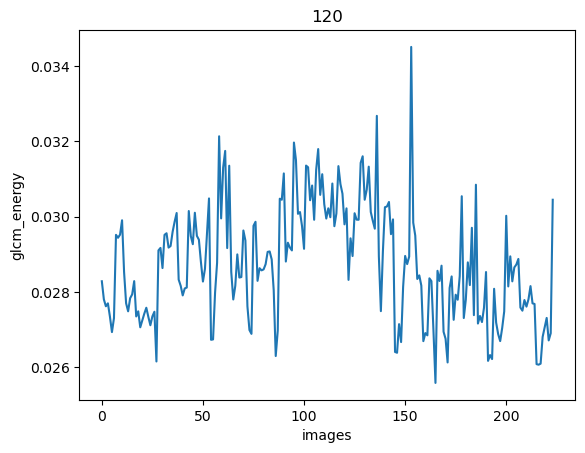

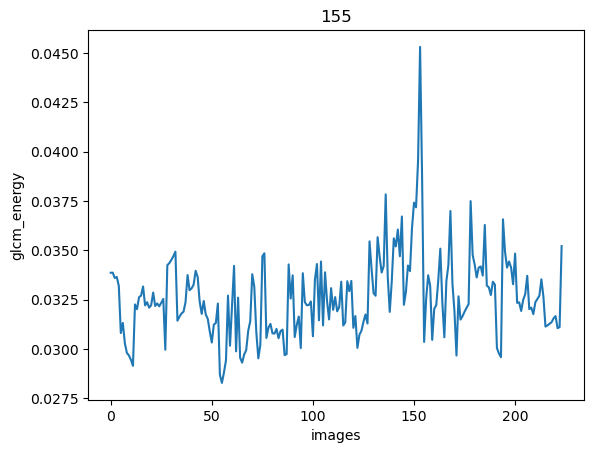

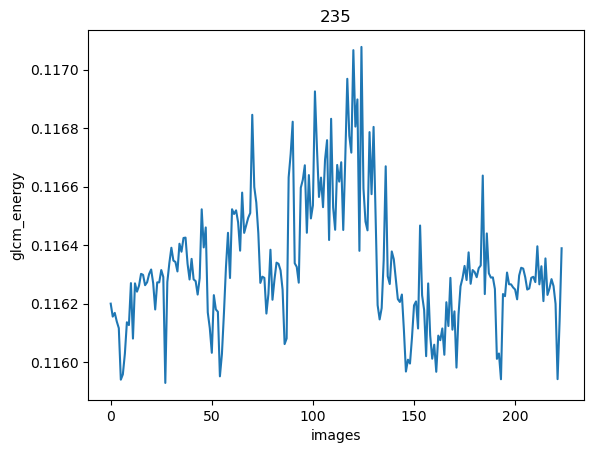

In [31]:
plot_baseline_from_feature(10, 'glcm_energy')
plot_baseline_from_feature(40, 'glcm_energy')
plot_baseline_from_feature(71, 'glcm_energy')
plot_baseline_from_feature(120, 'glcm_energy')
plot_baseline_from_feature(155, 'glcm_energy')
plot_baseline_from_feature(235, 'glcm_energy')


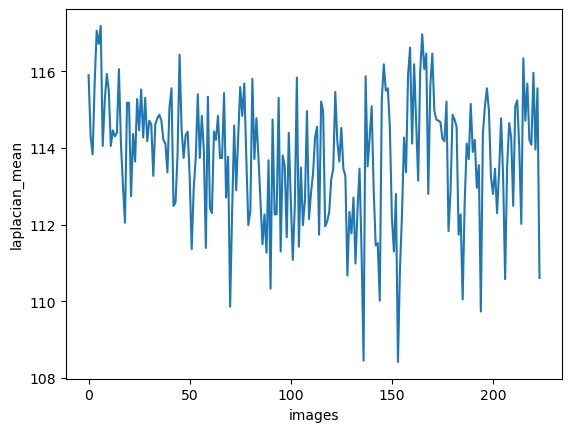

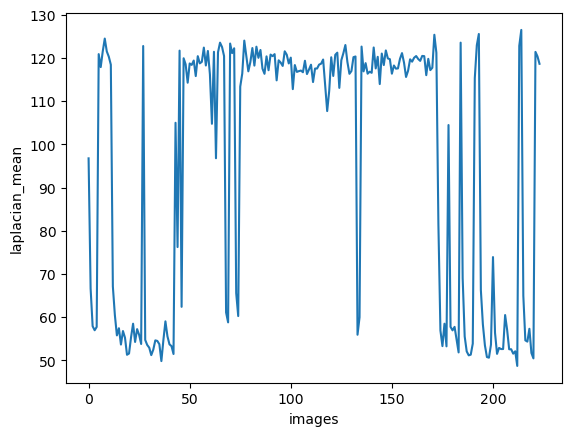

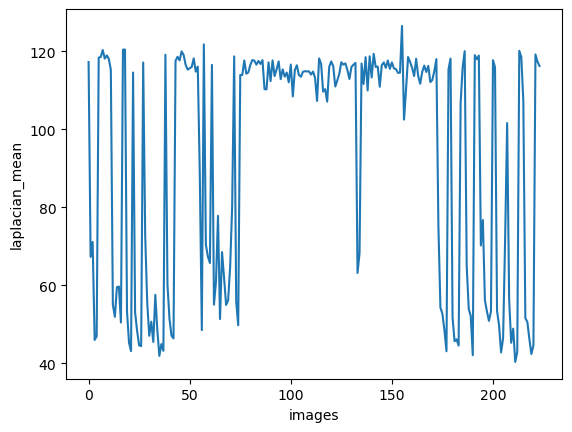

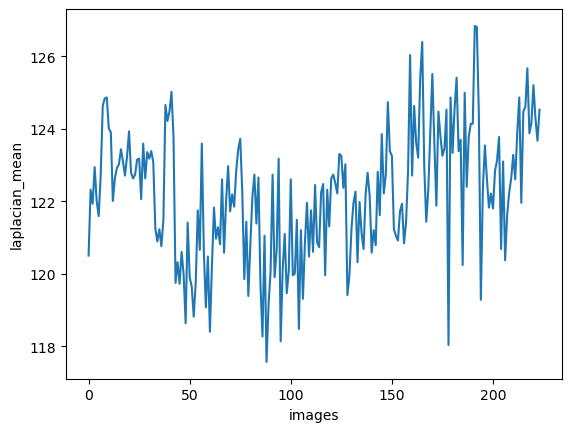

In [27]:
plot_baseline_from_feature(10, 'laplacian_mean')
plot_baseline_from_feature(40, 'laplacian_mean')
plot_baseline_from_feature(71, 'laplacian_mean')
plot_baseline_from_feature(155, 'laplacian_mean')

In [16]:
df_one_mirror = df[df["mirror_id"] == 40].reset_index()

In [17]:
df_one_mirror

,index,glcm_contrast,glcm_dissimilarity,glcm_homogeneity,glcm_energy,glcm_correlation,lbp_entropy,lbp_uniformity,sobel_mean,laplacian_mean,laplacian_std,edge_density,image_idx,mirror_id,filename
0,40,946.080811,11.252529,0.500650,0.223627,0.890516,2.824765,0.357753,6.871094,96.768417,110.131317,0.087810,0,40,IRCamM1T20251005_071000M.jpg
1,289,960.159424,10.465632,0.676344,0.504812,0.889283,2.153259,0.591575,4.328125,66.656898,98.503311,0.087607,1,40,IRCamM1T20251005_072000M.jpg
2,538,872.676819,9.280874,0.723419,0.549824,0.891300,1.970380,0.637871,3.671875,57.930809,94.489265,0.068885,2,40,IRCamM1T20251005_073000M.jpg
3,787,846.165405,8.996527,0.730200,0.564755,0.893208,1.930182,0.645910,3.570312,56.993080,94.426476,0.065527,3,40,IRCamM1T20251005_074000M.jpg
4,1036,856.259888,9.201966,0.728737,0.571414,0.892308,1.908056,0.655881,3.654297,57.748474,94.428360,0.068173,4,40,IRCamM1T20251005_075000M.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,54571,945.549072,8.685026,0.762321,0.629268,0.865103,1.762741,0.692511,3.279297,51.731380,91.486534,0.056675,219,40,IRCamM1T20251025_080000M.jpg
220,54820,820.586975,7.569350,0.777620,0.641790,0.877121,1.739976,0.697293,3.123047,50.481075,91.646179,0.051587,220,40,IRCamM1T20251025_081000M.jpg
221,55069,651.768433,12.247271,0.205048,0.039761,0.857860,3.206453,0.174603,10.023438,121.409851,111.175980,0.115995,221,40,IRCamM1T20251025_130557M.jpg
222,55318,635.915161,12.249943,0.220632,0.052247,0.832536,3.216210,0.166565,9.953125,120.367928,110.910225,0.112637,222,40,IRCamM1T20251025_133557M.jpg


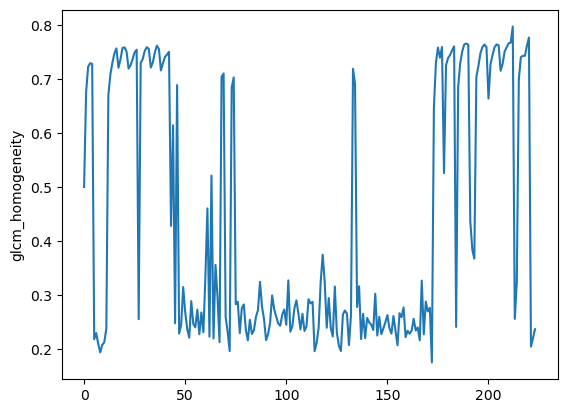

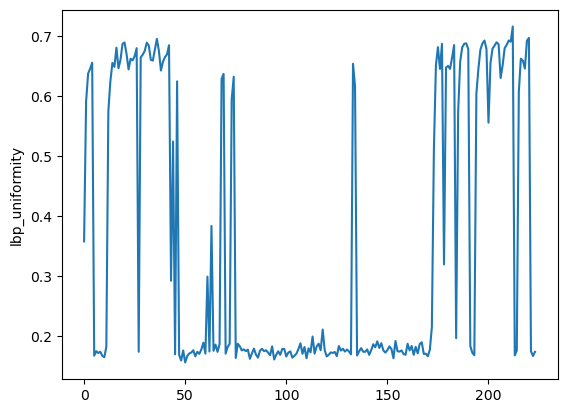

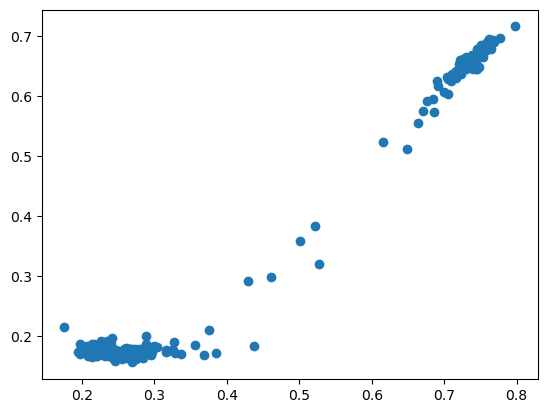

In [18]:
plt.figure()
df_one_mirror[features_keys_list[2]].plot()
plt.ylabel(features_keys_list[2])
plt.figure()
df_one_mirror[features_keys_list[6]].plot()
plt.ylabel(features_keys_list[6])
plt.figure()
plt.scatter(df_one_mirror[features_keys_list[2]], df_one_mirror[features_keys_list[6]])

In [24]:
np.corrcoef(df_one_mirror[features_keys_list[2]], df_one_mirror[features_keys_list[6]])

array([[ 1.        , -0.10681226],
       [-0.10681226,  1.        ]])

In [27]:
corr = df_one_mirror[['glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation']].corr()
corr.style.background_gradient(cmap='coolwarm')


,glcm_contrast,glcm_dissimilarity,glcm_homogeneity,glcm_energy,glcm_correlation
glcm_contrast,1.000000,0.510584,0.292581,0.145775,-0.213108
glcm_dissimilarity,0.510584,1.000000,-0.662244,-0.768087,0.560965
glcm_homogeneity,0.292581,-0.662244,1.000000,0.972601,-0.793009
glcm_energy,0.145775,-0.768087,0.972601,1.000000,-0.810343
glcm_correlation,-0.213108,0.560965,-0.793009,-0.810343,1.000000


## Corr all data points

[[1.         0.83113678]
 [0.83113678 1.        ]]


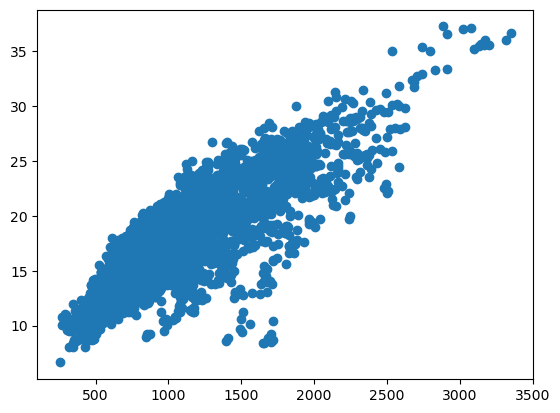

In [33]:
plot_corr(df['glcm_contrast'], df['glcm_dissimilarity'])

[[1.         0.07666831]
 [0.07666831 1.        ]]


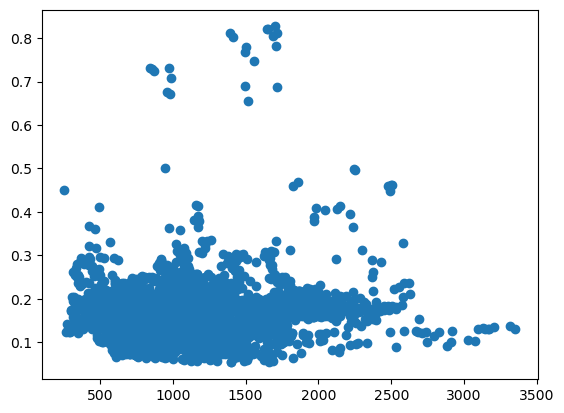

In [34]:
plot_corr(df['glcm_contrast'], df['glcm_homogeneity'])

[[1.         0.19061388]
 [0.19061388 1.        ]]


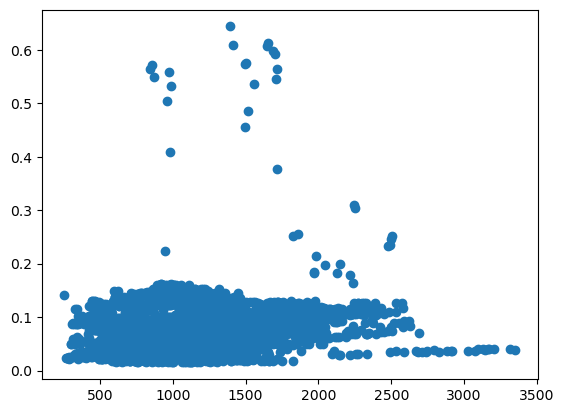

In [35]:
plot_corr(df['glcm_contrast'], df['glcm_energy'])